In [ ]:
# instalar dependências
#!pip install torch-geometric

In [ ]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import unicodedata
import networkx as nx
import glob
import pickle
from sklearn.preprocessing import MinMaxScaler
import torch
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression

In [ ]:
# ajuste de caminhos

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/Projeto Indicadores/data')
else:
    DATA_DIR = Path(r'C:\Users\Avell\Desktop\Projeto\data')

DBF_DIR_SIM = DATA_DIR / 'raw' / 'SIM'
CSV_DIR_SIH = DATA_DIR / 'raw' / 'SIH'
PARQUET_DIR_SIH = DATA_DIR / 'parquet' / 'SIH'
DIR_IBGE = DATA_DIR / 'raw' / 'IBGE'
AUX_DIR = DATA_DIR / 'auxiliary'
OUT_DIR = DATA_DIR / 'processed'
GEO_DIR = DATA_DIR / 'geo'
GRAPHML_DIR = DATA_DIR / 'graphml'
GNN_DIR = DATA_DIR / 'gnn'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MUN2RS_FILE = AUX_DIR / 'municipalities_health_regions_pr.xlsx'
RS_FILE = AUX_DIR / 'health_regions_pr.xlsx'
GRAPHML_FILE = GRAPHML_DIR / 'road_network_2hr.graphml'

DBF_DIR_SIM, MUN2RS_FILE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(PosixPath('/content/drive/MyDrive/Projeto Indicadores/data/raw/SIM'),
 PosixPath('/content/drive/MyDrive/Projeto Indicadores/data/auxiliary/municipalities_health_regions_pr.xlsx'))

In [ ]:
GNN_FILE_1 = GNN_DIR / 'graph_2025_jan.pkl'
GNN_FILE_2 = GNN_DIR / 'graph_2025_feb.pkl'
GNN_FILE_3 = GNN_DIR / 'graph_2025_mar.pkl'
GNN_FILE_4 = GNN_DIR / 'graph_2025_apr.pkl'
GNN_FILE_5 = GNN_DIR / 'graph_2025_may.pkl'
GNN_FILE_6 = GNN_DIR / 'graph_2025_jun.pkl'
GNN_FILE_7 = GNN_DIR / 'graph_2025_jul.pkl'
GNN_FILE_8 = GNN_DIR / 'graph_2025_aug.pkl'
GNN_FILE_9 = GNN_DIR / 'graph_2025_sep.pkl'
GNN_FILE_10 = GNN_DIR / 'graph_2025_oct.pkl'
GNN_FILE_11 = GNN_DIR / 'graph_2025_nov.pkl'
GNN_FILE_12 = GNN_DIR / 'graph_2025_dec.pkl'

In [ ]:
GNN_CSV_FILE_1 = GNN_DIR / 'features_2025_jan.csv'
GNN_CSV_FILE_2 = GNN_DIR / 'features_2025_feb.csv'
GNN_CSV_FILE_3 = GNN_DIR / 'features_2025_mar.csv'
GNN_CSV_FILE_4 = GNN_DIR / 'features_2025_apr.csv'
GNN_CSV_FILE_5 = GNN_DIR / 'features_2025_may.csv'
GNN_CSV_FILE_6 = GNN_DIR / 'features_2025_jun.csv'
GNN_CSV_FILE_7 = GNN_DIR / 'features_2025_jul.csv'
GNN_CSV_FILE_8 = GNN_DIR / 'features_2025_aug.csv'
GNN_CSV_FILE_9 = GNN_DIR / 'features_2025_sep.csv'
GNN_CSV_FILE_10 = GNN_DIR / 'features_2025_oct.csv'
GNN_CSV_FILE_11 = GNN_DIR / 'features_2025_nov.csv'
GNN_CSV_FILE_12 = GNN_DIR / 'features_2025_dec.csv'

In [ ]:
with open(GNN_FILE_1, "rb") as f:
    G_map_1 = pickle.load(f)

with open(GNN_FILE_2, "rb") as f:
    G_map_2 = pickle.load(f)

with open(GNN_FILE_3, "rb") as f:
    G_map_3 = pickle.load(f)

with open(GNN_FILE_4, "rb") as f:
    G_map_4 = pickle.load(f)

with open(GNN_FILE_5, "rb") as f:
    G_map_5 = pickle.load(f)

with open(GNN_FILE_6, "rb") as f:
    G_map_6 = pickle.load(f)

with open(GNN_FILE_7, "rb") as f:
    G_map_7 = pickle.load(f)

with open(GNN_FILE_8, "rb") as f:
    G_map_8 = pickle.load(f)

with open(GNN_FILE_9, "rb") as f:
    G_map_9 = pickle.load(f)

with open(GNN_FILE_10, "rb") as f:
    G_map_10 = pickle.load(f)

with open(GNN_FILE_11, "rb") as f:
    G_map_11 = pickle.load(f)

with open(GNN_FILE_12, "rb") as f:
    G_map_12 = pickle.load(f)

In [ ]:
features_jan = pd.read_csv(GNN_CSV_FILE_1)
features_fev = pd.read_csv(GNN_CSV_FILE_2)
features_mar = pd.read_csv(GNN_CSV_FILE_3)
features_abr = pd.read_csv(GNN_CSV_FILE_4)
features_mai = pd.read_csv(GNN_CSV_FILE_5)
features_jun = pd.read_csv(GNN_CSV_FILE_6)
features_jul = pd.read_csv(GNN_CSV_FILE_7)
features_ago = pd.read_csv(GNN_CSV_FILE_8)
features_set = pd.read_csv(GNN_CSV_FILE_9)
features_out = pd.read_csv(GNN_CSV_FILE_10)
features_nov = pd.read_csv(GNN_CSV_FILE_11)
features_dez = pd.read_csv(GNN_CSV_FILE_12)

In [ ]:
features_jan['codigo_ibge'] = (features_jan['codigo_ibge'].astype(float).astype(int).astype(str))
features_fev['codigo_ibge'] = (features_fev['codigo_ibge'].astype(float).astype(int).astype(str))
features_mar['codigo_ibge'] = (features_mar['codigo_ibge'].astype(float).astype(int).astype(str))
features_abr['codigo_ibge'] = (features_abr['codigo_ibge'].astype(float).astype(int).astype(str))
features_mai['codigo_ibge'] = (features_mai['codigo_ibge'].astype(float).astype(int).astype(str))
features_jun['codigo_ibge'] = (features_jun['codigo_ibge'].astype(float).astype(int).astype(str))
features_jul['codigo_ibge'] = (features_jul['codigo_ibge'].astype(float).astype(int).astype(str))
features_ago['codigo_ibge'] = (features_ago['codigo_ibge'].astype(float).astype(int).astype(str))
features_set['codigo_ibge'] = (features_set['codigo_ibge'].astype(float).astype(int).astype(str))
features_out['codigo_ibge'] = (features_out['codigo_ibge'].astype(float).astype(int).astype(str))
features_nov['codigo_ibge'] = (features_nov['codigo_ibge'].astype(float).astype(int).astype(str))
features_dez['codigo_ibge'] = (features_dez['codigo_ibge'].astype(float).astype(int).astype(str))

In [ ]:
grafos_mensais = {
    1: G_map_1,
    2: G_map_2,
    3: G_map_3,
    4: G_map_4,
    5: G_map_5,
    6: G_map_6,
    7: G_map_7,
    8: G_map_8,
    9: G_map_9,
    10: G_map_10,
    11: G_map_11,
    12: G_map_12
}

In [ ]:
features_mensais = {
    1: features_jan,
    2: features_fev,
    3: features_mar,
    4: features_abr,
    5: features_mai,
    6: features_jun,
    7: features_jul,
    8: features_ago,
    9: features_set,
    10: features_out,
    11: features_nov,
    12: features_dez
}

In [ ]:
for mes, df in features_mensais.items():
    print(f"\nMês {mes}")
    print(df.columns.tolist())
    print(df.head())


Mês 1
['codigo_ibge', 'total', 'fora', 'export_pct', 'para_curitiba', 'dep_curitiba', 'distancia_km', 'tempo_min']
  codigo_ibge  total  fora  export_pct  para_curitiba  dep_curitiba  \
0      410020      5     5     1.00000            5.0      1.000000   
1      410030      9     9     1.00000            6.0      0.666667   
2      410040    142   142     1.00000          111.0      0.781690   
3      410180    167    10     0.05988            6.0      0.600000   
4      410230      9     9     1.00000            0.0      0.000000   

   distancia_km  tempo_min  
0         127.3      134.0  
1          68.4       65.1  
2          15.6       19.9  
3          25.5       31.3  
4          48.9       44.6  

Mês 2
['codigo_ibge', 'total', 'fora', 'export_pct', 'para_curitiba', 'dep_curitiba', 'distancia_km', 'tempo_min']
  codigo_ibge  total   fora  export_pct  para_curitiba  dep_curitiba  \
0      410020    4.0    4.0    1.000000            2.0      0.500000   
1      410030   11.0   

In [ ]:
todos_codigos = [
    '410020', '410030', '410040', '410180', '410230', '410310',
    '410400', '410410', '410420', '410425', '410520', '410580',
    '410620', '410690', '412863', '410765', '411125', '411320',
    '411430', '411910', '411915', '411950', '412080', '412120',
    '412220', '412230', '412550', '412760', '412788'
]

for mes in range(1, 13):
    grafos_mensais[mes].add_nodes_from(todos_codigos)

In [ ]:
linha_curitiba = {
    "codigo_ibge": '410690',
    "total": 0,
    "fora": 0,
    "export_pct": 0,
    "para_curitiba": 0,
    "dep_curitiba": 0,
    "distancia_km": 0,
    "tempo_min": 0
}

In [ ]:
for mes in range(1, 13):
    if '410690' not in features_mensais[mes]["codigo_ibge"].values:
        features_mensais[mes] = pd.concat(
            [features_mensais[mes], pd.DataFrame([linha_curitiba])],
            ignore_index=True
        )

In [ ]:
for mes in range(1, 13):
    G = grafos_mensais[mes]
    df = features_mensais[mes]

    nos_grafo = set(G.nodes())
    codigos_features = set(df["codigo_ibge"])

    print(f"Mês {mes}")
    print("Nós no grafo:", len(nos_grafo))
    print("Municípios nas features:", len(codigos_features))
    print("Nós sem features:", len(nos_grafo - codigos_features))
    print("Features sem nó:", len(codigos_features - nos_grafo))
    print()

Mês 1
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 2
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 3
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 4
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 5
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 6
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 7
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 8
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 9
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 10
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 0

Mês 11
Nós no grafo: 29
Municípios nas features: 29
Nós sem features: 0
Features sem nó: 

In [ ]:
colunas_features = [
    "total",
    "fora",
    "export_pct",
    "para_curitiba",
    "dep_curitiba",
    "distancia_km",
    "tempo_min"
]

scaler = MinMaxScaler()

for mes in range(1, 13):

    df = features_mensais[mes].copy()

    df[colunas_features] = scaler.fit_transform(
        df[colunas_features]
    )

    features_mensais[mes] = df

In [ ]:
for mes in range(1, 13):

    df = features_mensais[mes]

    df["indice_vulnerabilidade"] = (
        0.4 * df["dep_curitiba"] +
        0.3 * df["para_curitiba"] +
        0.2 * df["tempo_min"] +
        0.1 * df["distancia_km"]
    )

    features_mensais[mes] = df

In [ ]:
def classificar(v):

    if v < 0.33:
        return 0

    elif v < 0.66:
        return 1

    else:
        return 2

In [ ]:
for mes in range(1, 13):
    df = features_mensais[mes].copy()

    df["classe_vulnerabilidade"] = (
        df["indice_vulnerabilidade"]
        .apply(classificar)
    )

    features_mensais[mes] = df

In [ ]:
for mes in range(1, 13):
    print(f"Mês {mes}")
    print(features_mensais[mes]["classe_vulnerabilidade"].value_counts())
    print()

Mês 1
classe_vulnerabilidade
0    15
1    12
2     2
Name: count, dtype: int64

Mês 2
classe_vulnerabilidade
0    15
1    13
2     1
Name: count, dtype: int64

Mês 3
classe_vulnerabilidade
0    15
1    13
2     1
Name: count, dtype: int64

Mês 4
classe_vulnerabilidade
0    16
1    11
2     2
Name: count, dtype: int64

Mês 5
classe_vulnerabilidade
0    15
1    13
2     1
Name: count, dtype: int64

Mês 6
classe_vulnerabilidade
0    15
1    13
2     1
Name: count, dtype: int64

Mês 7
classe_vulnerabilidade
0    15
1    13
2     1
Name: count, dtype: int64

Mês 8
classe_vulnerabilidade
0    15
1    13
2     1
Name: count, dtype: int64

Mês 9
classe_vulnerabilidade
1    15
0    13
2     1
Name: count, dtype: int64

Mês 10
classe_vulnerabilidade
1    14
0    13
2     2
Name: count, dtype: int64

Mês 11
classe_vulnerabilidade
0    15
1    13
2     1
Name: count, dtype: int64

Mês 12
classe_vulnerabilidade
0    15
1    12
2     2
Name: count, dtype: int64



In [ ]:
colunas_x = [
    "total",
    "fora",
    "export_pct",
    "para_curitiba",
    "dep_curitiba",
    "distancia_km",
    "tempo_min"
]

In [ ]:
data_list = []

for mes in range(1, 13):
    G = grafos_mensais[mes]
    df = features_mensais[mes].copy()

    df = df.set_index("codigo_ibge")
    nodes = list(G.nodes())

    x = torch.tensor(
        df.loc[nodes, colunas_x].values,
        dtype=torch.float
    )

    y = torch.tensor(
        df.loc[nodes, "classe_vulnerabilidade"].values,
        dtype=torch.long
    )

    node_to_idx = {node: i for i, node in enumerate(nodes)}

    edge_index = torch.tensor(
        [[node_to_idx[u], node_to_idx[v]] for u, v in G.edges()],
        dtype=torch.long
    ).t().contiguous()

    data = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    data.mes = mes
    data_list.append(data)

In [ ]:
for data in data_list:
    print(
        "Mês:", data.mes,
        "| x:", data.x.shape,
        "| edge_index:", data.edge_index.shape,
        "| y:", data.y.shape
    )

Mês: 1 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 19]) | y: torch.Size([29])
Mês: 2 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 22]) | y: torch.Size([29])
Mês: 3 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 20]) | y: torch.Size([29])
Mês: 4 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 21]) | y: torch.Size([29])
Mês: 5 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 20]) | y: torch.Size([29])
Mês: 6 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 19]) | y: torch.Size([29])
Mês: 7 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 21]) | y: torch.Size([29])
Mês: 8 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 23]) | y: torch.Size([29])
Mês: 9 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 20]) | y: torch.Size([29])
Mês: 10 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 21]) | y: torch.Size([29])
Mês: 11 | x: torch.Size([29, 7]) | edge_index: torch.Size([2, 20]) | y: torch.Size([29])
Mês: 12 | x: torch.Size([29, 7

In [ ]:
# Teste para o mês de janeiro

data = data_list[0]  # janeiro

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model = GCN(in_channels=7, hidden_channels=16, out_channels=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out, data.y)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        pred = out.argmax(dim=1)
        acc = (pred == data.y).sum().item() / data.y.size(0)
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Acc: {acc:.4f}")

Epoch 000 | Loss: 1.2916 | Acc: 0.1379
Epoch 020 | Loss: 0.7329 | Acc: 0.8621
Epoch 040 | Loss: 0.5398 | Acc: 0.8621
Epoch 060 | Loss: 0.4134 | Acc: 0.8621
Epoch 080 | Loss: 0.3131 | Acc: 0.8966
Epoch 100 | Loss: 0.2441 | Acc: 0.8966
Epoch 120 | Loss: 0.2028 | Acc: 0.9310
Epoch 140 | Loss: 0.1773 | Acc: 0.9310
Epoch 160 | Loss: 0.1598 | Acc: 0.9310
Epoch 180 | Loss: 0.1471 | Acc: 0.9310


In [ ]:
num_nodes = data.num_nodes

perm = torch.randperm(num_nodes)

train_size = int(0.7 * num_nodes)

train_idx = perm[:train_size]
test_idx = perm[train_size:]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask

In [ ]:
model = GCN(in_channels=7, hidden_channels=16, out_channels=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        model.eval()
        pred = out.argmax(dim=1)

        train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
        test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 000 | Loss: 1.3716 | Train Acc: 0.0000 | Test Acc: 0.3333
Epoch 020 | Loss: 0.6612 | Train Acc: 0.5500 | Test Acc: 0.4444
Epoch 040 | Loss: 0.4435 | Train Acc: 0.9000 | Test Acc: 0.7778
Epoch 060 | Loss: 0.3324 | Train Acc: 0.9000 | Test Acc: 0.7778
Epoch 080 | Loss: 0.2539 | Train Acc: 0.9500 | Test Acc: 0.7778
Epoch 100 | Loss: 0.1830 | Train Acc: 0.9500 | Test Acc: 0.7778
Epoch 120 | Loss: 0.1257 | Train Acc: 1.0000 | Test Acc: 0.7778
Epoch 140 | Loss: 0.0801 | Train Acc: 1.0000 | Test Acc: 0.7778
Epoch 160 | Loss: 0.0520 | Train Acc: 1.0000 | Test Acc: 0.7778
Epoch 180 | Loss: 0.0317 | Train Acc: 1.0000 | Test Acc: 0.7778


In [ ]:
# Treinamento usando os 12 meses
resultados = []

for i, data in enumerate(data_list, start=1):

    num_nodes = data.num_nodes
    perm = torch.randperm(num_nodes)

    train_size = int(0.7 * num_nodes)
    train_idx = perm[:train_size]
    test_idx = perm[train_size:]

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    test_mask[test_idx] = True

    data.train_mask = train_mask
    data.test_mask = test_mask

    model = GCN(in_channels=7, hidden_channels=16, out_channels=3)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    train_acc = (
        pred[data.train_mask] == data.y[data.train_mask]
    ).sum().item() / data.train_mask.sum().item()

    test_acc = (
        pred[data.test_mask] == data.y[data.test_mask]
    ).sum().item() / data.test_mask.sum().item()

    resultados.append({
        "mes": i,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "loss": loss.item()
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

,mes,train_acc,test_acc,loss
0,1,1.00,0.777778,0.092897
1,2,1.00,0.888889,0.098215
2,3,0.90,0.777778,0.111080
3,4,0.95,0.777778,0.153560
4,5,1.00,0.888889,0.089506
5,6,0.95,0.777778,0.079651
6,7,1.00,0.666667,0.098538
7,8,0.90,1.000000,0.231030
8,9,0.90,0.888889,0.222897
9,10,0.95,0.888889,0.122964


In [ ]:
resultados_df.describe()

,mes,train_acc,test_acc,loss
count,12.000000,12.00000,12.000000,12.000000
mean,6.500000,0.95000,0.833333,0.134827
std,3.605551,0.04264,0.088636,0.052046
min,1.000000,0.90000,0.666667,0.079651
25%,3.750000,0.90000,0.777778,0.096885
50%,6.500000,0.95000,0.833333,0.117022
75%,9.250000,1.00000,0.888889,0.160645
max,12.000000,1.00000,1.000000,0.231030


In [ ]:
# Generalização temporal
train_data = data_list[:9]
test_data = data_list[9:]

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

In [ ]:
model = GCN(
    in_channels=7,
    hidden_channels=16,
    out_channels=3
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

for epoch in range(200):

    model.train()

    total_loss = 0

    for data in train_data:

        optimizer.zero_grad()

        out = model(data.x, data.edge_index)

        loss = F.cross_entropy(out, data.y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {total_loss / len(train_data):.4f}"
        )

Epoch 000 | Loss: 0.8464
Epoch 020 | Loss: 0.2990
Epoch 040 | Loss: 0.2527
Epoch 060 | Loss: 0.2254
Epoch 080 | Loss: 0.1944
Epoch 100 | Loss: 0.1626
Epoch 120 | Loss: 0.1421
Epoch 140 | Loss: 0.1297
Epoch 160 | Loss: 0.1216
Epoch 180 | Loss: 0.1158


In [ ]:
model.eval()

y_true = []
y_pred = []

for data in test_data:

    out = model(data.x, data.edge_index)

    pred = out.argmax(dim=1)

    y_true.extend(data.y.cpu().numpy())
    y_pred.extend(pred.cpu().numpy())

In [ ]:
acc = accuracy_score(y_true, y_pred)

print("Accuracy:", acc)

Accuracy: 0.9310344827586207


In [ ]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.89      1.00      0.94        39
           2       0.67      0.40      0.50         5

    accuracy                           0.93        87
   macro avg       0.85      0.78      0.80        87
weighted avg       0.93      0.93      0.93        87



In [ ]:
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

[[40  2  1]
 [ 0 39  0]
 [ 0  3  2]]


In [ ]:
# Usando Random Forest
colunas_x = [
    "total",
    "fora",
    "export_pct",
    "para_curitiba",
    "dep_curitiba",
    "distancia_km",
    "tempo_min"
]

# montar treino: meses 1 a 9
X_train = []
y_train = []

for mes in range(1, 10):
    df = features_mensais[mes].copy()
    X_train.append(df[colunas_x])
    y_train.append(df["classe_vulnerabilidade"])

X_train = pd.concat(X_train, ignore_index=True)
y_train = pd.concat(y_train, ignore_index=True)

# montar teste: meses 10 a 12
X_test = []
y_test = []

for mes in range(10, 13):
    df = features_mensais[mes].copy()
    X_test.append(df[colunas_x])
    y_test.append(df["classe_vulnerabilidade"])

X_test = pd.concat(X_test, ignore_index=True)
y_test = pd.concat(y_test, ignore_index=True)

# treinar Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# prever
y_pred_rf = rf.predict(X_test)

# métricas
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))
print()
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9310344827586207

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        43
           1       0.92      0.92      0.92        39
           2       1.00      0.60      0.75         5

    accuracy                           0.93        87
   macro avg       0.95      0.83      0.88        87
weighted avg       0.93      0.93      0.93        87


[[42  1  0]
 [ 3 36  0]
 [ 0  2  3]]


In [ ]:
# Usando Logistic Regression
# colunas utilizadas
colunas_x = [
    "total",
    "fora",
    "export_pct",
    "para_curitiba",
    "dep_curitiba",
    "distancia_km",
    "tempo_min"
]

# =========================
# TREINO
# =========================

X_train = []
y_train = []

for mes in range(1, 10):

    df = features_mensais[mes].copy()

    X_train.append(df[colunas_x])
    y_train.append(df["classe_vulnerabilidade"])

X_train = pd.concat(X_train, ignore_index=True)
y_train = pd.concat(y_train, ignore_index=True)

# =========================
# TESTE
# =========================

X_test = []
y_test = []

for mes in range(10, 13):

    df = features_mensais[mes].copy()

    X_test.append(df[colunas_x])
    y_test.append(df["classe_vulnerabilidade"])

X_test = pd.concat(X_test, ignore_index=True)
y_test = pd.concat(y_test, ignore_index=True)

# =========================
# MODELO
# =========================

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

# =========================
# PREVISÃO
# =========================

y_pred_lr = log_reg.predict(X_test)

# =========================
# MÉTRICAS
# =========================

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print()

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

print()

print(
    confusion_matrix(
        y_test,
        y_pred_lr
    )
)

Accuracy: 0.9540229885057471

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        43
           1       0.97      0.92      0.95        39
           2       1.00      0.80      0.89         5

    accuracy                           0.95        87
   macro avg       0.97      0.91      0.93        87
weighted avg       0.96      0.95      0.95        87


[[43  0  0]
 [ 3 36  0]
 [ 0  1  4]]


In [ ]:
coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=colunas_x
)

coef_df.index = [
    "classe_0",
    "classe_1",
    "classe_2"
]

coef_df

,total,fora,export_pct,para_curitiba,dep_curitiba,distancia_km,tempo_min
classe_0,0.126657,-0.314831,-0.768243,-1.196816,-4.385746,-1.079121,-0.956755
classe_1,-0.950877,-1.029659,0.192645,-0.145929,1.698909,-1.197632,-1.606148
classe_2,0.824220,1.344490,0.575598,1.342746,2.686837,2.276753,2.562903


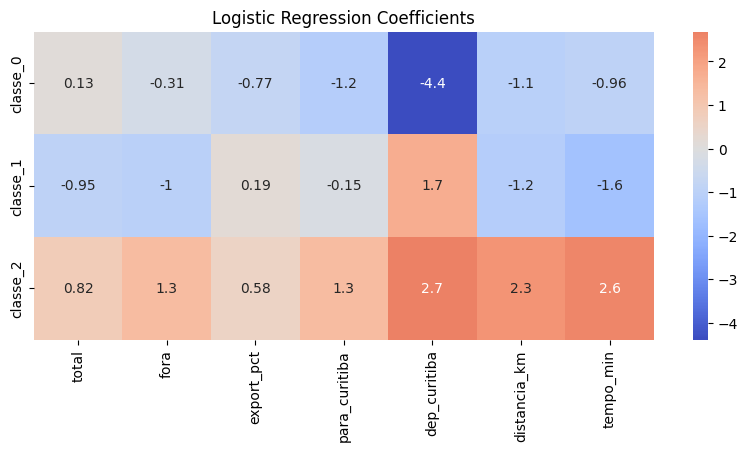

In [ ]:
plt.figure(figsize=(10, 4))

sns.heatmap(
    coef_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Logistic Regression Coefficients")
plt.show()

In [ ]:
# Tabela comparativa
def calcular_metricas(nome_modelo, y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    precision_classes, recall_classes, f1_classes, support_classes = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        zero_division=0
    )

    return {
        "Model": nome_modelo,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
        "F1 Class 0": f1_classes[0],
        "F1 Class 1": f1_classes[1],
        "F1 Class 2": f1_classes[2],
        "Support Class 0": support_classes[0],
        "Support Class 1": support_classes[1],
        "Support Class 2": support_classes[2]
    }

tabela_comparativa = pd.DataFrame([
    calcular_metricas("GCN", y_true, y_pred),
    calcular_metricas("Random Forest", y_test, y_pred_rf),
    calcular_metricas("Logistic Regression", y_test, y_pred_lr)
])

tabela_comparativa

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,F1 Class 0,F1 Class 1,F1 Class 2,Support Class 0,Support Class 1,Support Class 2
0,GCN,0.931034,0.851010,0.776744,0.801205,0.926395,0.963855,0.939759,0.500000,43,39,5
1,Random Forest,0.931034,0.952137,0.833274,0.875874,0.928683,0.954545,0.923077,0.750000,43,39,5
2,Logistic Regression,0.954023,0.969252,0.907692,0.934183,0.953361,0.966292,0.947368,0.888889,43,39,5


In [ ]:
tabela_comparativa_formatada = tabela_comparativa.copy()

colunas_metricas = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
    "F1 Class 0",
    "F1 Class 1",
    "F1 Class 2"
]

tabela_comparativa_formatada[colunas_metricas] = (
    tabela_comparativa_formatada[colunas_metricas]
    .round(3)
)

tabela_comparativa_formatada

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,F1 Class 0,F1 Class 1,F1 Class 2,Support Class 0,Support Class 1,Support Class 2
0,GCN,0.931,0.851,0.777,0.801,0.926,0.964,0.940,0.500,43,39,5
1,Random Forest,0.931,0.952,0.833,0.876,0.929,0.955,0.923,0.750,43,39,5
2,Logistic Regression,0.954,0.969,0.908,0.934,0.953,0.966,0.947,0.889,43,39,5
